Libraries Loaded Successfully

Dataset Path Found:
/kaggle/input/datasets/kavanacv/creditcard-23/credit_card_frauds.csv

Dataset Loaded Successfully

First 5 Rows:
  trans_date_trans_time                   merchant       category     amt  \
0   2019-01-01 00:00:44  Heller, Gutmann and Zieme    grocery_pos  107.23   
1   2019-01-01 00:00:51             Lind-Buckridge  entertainment  220.11   
2   2019-01-01 00:07:27                  Kiehn Inc    grocery_pos   96.29   
3   2019-01-01 00:09:03                Beier-Hyatt   shopping_pos    7.77   
4   2019-01-01 00:21:32                 Bruen-Yost       misc_pos    6.85   

                       city state      lat      long  city_pop  \
0                    Orient    WA  48.8878 -118.2105       149   
1                Malad City    ID  42.1808 -112.2620      4154   
2                   Grenada    CA  41.6125 -122.5258       589   
3  High Rolls Mountain Park    NM  32.9396 -105.8189       899   
4                   Freedom    WY  43.0172 

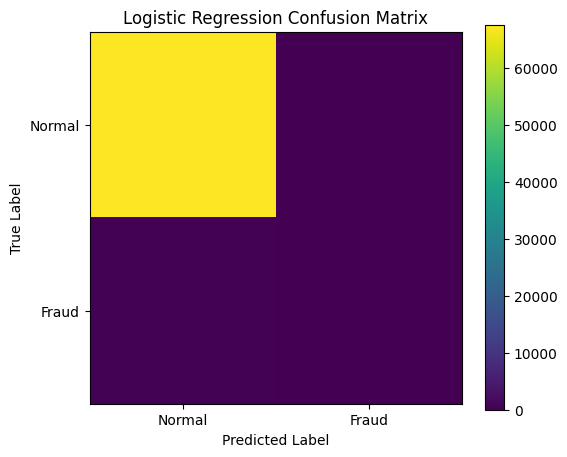


Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     67555
           1       0.00      0.00      0.00       367

    accuracy                           0.99     67922
   macro avg       0.50      0.50      0.50     67922
weighted avg       0.99      0.99      0.99     67922


RQ3 Completed Successfully


In [1]:
# =========================================
# RQ3 - Logistic Regression Model
# =========================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries Loaded Successfully")

# =========================================
# FIND DATASET AUTOMATICALLY
# =========================================

csv_path = ""

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            csv_path = os.path.join(dirname, filename)

print("\nDataset Path Found:")
print(csv_path)

# =========================================
# LOAD DATASET
# =========================================

data = pd.read_csv(csv_path)

print("\nDataset Loaded Successfully")

# Display First 5 Rows
print("\nFirst 5 Rows:")
print(data.head())

# =========================================
# PREPROCESSING
# =========================================

# Keep only numeric columns
data_numeric = data.select_dtypes(include=['int64', 'float64'])

# Features and Target
X = data_numeric.drop("is_fraud", axis=1)
y = data_numeric["is_fraud"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nData Split Completed")

# =========================================
# LOGISTIC REGRESSION MODEL
# =========================================

model = LogisticRegression(max_iter=1000)

# Train Model
model.fit(X_train, y_train)

print("\nModel Training Completed")

# Predictions
y_pred = model.predict(X_test)

# =========================================
# EVALUATION METRICS
# =========================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Results Table
results_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Value": [accuracy, precision, recall, f1]
})

print("\nModel Performance:")
print(results_table)

# Save Results Table
results_table.to_csv(
    "RQ3_Logistic_Regression_Results.csv",
    index=False
)

# =========================================
# CONFUSION MATRIX GRAPH
# =========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.title("Logistic Regression Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0,1], ["Normal","Fraud"])
plt.yticks([0,1], ["Normal","Fraud"])

plt.show()

# =========================================
# CLASSIFICATION REPORT
# =========================================

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nRQ3 Completed Successfully")